# Section 2.2 Tuning Hyperparameters for Independent Random Forest Models

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5), "Python 3.5 or later is required."

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20", "Scikit-Learn 0.20 or later is required."

# Common imports
import os
import time
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# Configure Matplotlib and Seaborn
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
sns.set()

# Machine learning libraries
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, cross_validate

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Import the tune_random_forest function from the tuning_utils.py file
from rf_utils import tune_random_forest

In [3]:
def run_tuning_on_datasets(x_files, y_files, dataset_label):
    """
    Tune Random Forest models on multiple training datasets and store the results.

    Parameters:
    - x_files (list): List of file paths for the feature datasets (X).
    - y_files (list): List of file paths for the target datasets (y).
    - dataset_label (str): Label to identify the dataset type (e.g., "FSO", "RF").

    Returns:
    - results (list): List of dictionaries containing tuning results for each dataset.
    """
    results = []
    for x_file, y_file in zip(x_files, y_files):
        # Load datasets
        X_train = pd.read_csv(x_file)
        y_train = pd.read_csv(y_file).squeeze()
        
        # Call the tuning function
        best_params, mean_rmse, std_rmse = tune_random_forest(X_train, y_train)

        # Extract model name from the file path
        file_name = os.path.basename(x_file)  # Extract the file name
        if "Generic" in file_name:
            model_name = "Generic"
        elif "Specific" in file_name:
            model_name = file_name.split('_')[1]  
        else:
            model_name = "Unknown"
        
        # Store results
        result = {
            'Model': model_name, 
            'Best Params': best_params,
            'Mean RMSE': mean_rmse,
            'Std RMSE': std_rmse
        }
        results.append(result)

        # Print results for the current model
        print(f"Results for {dataset_label} - {model_name}:")
        print(f"  Best Params: {best_params}")
        print(f"  Mean RMSE: {mean_rmse:.4f}")
        print(f"  Std RMSE: {std_rmse:.4f}")
        print('')

    return results

In [4]:
# Define the paths to the training datasets  

fso_train_files = [
    "Data/Splitting/Train/Generic/X/updated_Generic_FSO.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific0_FSO.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific3_FSO.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific4_FSO.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific5_FSO.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific6_FSO.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific7_FSO.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific8_FSO.csv"
]

rf_train_files = [
    "Data/Splitting/Train/Generic/X/updated_Generic_RF.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific0_RF.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific3_RF.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific4_RF.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific5_RF.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific6_RF.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific7_RF.csv",
    "Data/Splitting/Train/Specific/X/updated_Specific8_RF.csv"
]

y_fso_train_files = [
    "Data/Splitting/Train/Generic/Y/y_train_FSO.csv",
    "Data/Splitting/Train/Specific/Y/train_y_FSO_SC_0.csv",
    "Data/Splitting/Train/Specific/Y/train_y_FSO_SC_3.csv",
    "Data/Splitting/Train/Specific/Y/train_y_FSO_SC_4.csv",
    "Data/Splitting/Train/Specific/Y/train_y_FSO_SC_5.csv",
    "Data/Splitting/Train/Specific/Y/train_y_FSO_SC_6.csv",
    "Data/Splitting/Train/Specific/Y/train_y_FSO_SC_7.csv",
    "Data/Splitting/Train/Specific/Y/train_y_FSO_SC_8.csv"
]

y_rf_train_files = [
    "Data/Splitting/Train/Generic/Y/y_train_RF.csv",
    "Data/Splitting/Train/Specific/Y/train_y_RF_SC_0.csv",
    "Data/Splitting/Train/Specific/Y/train_y_RF_SC_3.csv",
    "Data/Splitting/Train/Specific/Y/train_y_RF_SC_4.csv",
    "Data/Splitting/Train/Specific/Y/train_y_RF_SC_5.csv",
    "Data/Splitting/Train/Specific/Y/train_y_RF_SC_6.csv",
    "Data/Splitting/Train/Specific/Y/train_y_RF_SC_7.csv",
    "Data/Splitting/Train/Specific/Y/train_y_RF_SC_8.csv"
]

**(1) Model Training and Hyperparameter Tuning for FSO Attenuation**

In [5]:
# Run tuning for FSO datasets
fso_train_results = run_tuning_on_datasets(fso_train_files, y_fso_train_files, "FSO")

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mean RMSE: 1.1539
Standard Deviation of RMSE: 0.0242
Results for FSO - Generic:
  Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Mean RMSE: 1.1539
  Std RMSE: 0.0242

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mean RMSE: 1.2202
Standard Deviation of RMSE: 0.0253
Results for FSO - Specific0:
  Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Mean RMSE: 1.2202
  Std RMSE: 0.0253

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Mean RMSE: 2.5027
Standard Deviation of RMSE: 0.4039
Results for FSO - Specific3:
  Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
  Mean RMSE: 2.5027
  Std RMSE: 0.4039

Best Parameters: {

In [6]:
# Separate the generic model from specific models in results
generic_fso_model = fso_train_results[0]  
specific_fso_models = fso_train_results[1:]  # The rest are Specific models

**(2) Model Training and Hyperparameter Tuning for RF Attenuation**

In [7]:
# Run tuning for RF datasets
rf_train_results = run_tuning_on_datasets(rf_train_files, y_rf_train_files, "RF")

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mean RMSE: 0.7688
Standard Deviation of RMSE: 0.0230
Results for RF - Generic:
  Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Mean RMSE: 0.7688
  Std RMSE: 0.0230

Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mean RMSE: 0.4866
Standard Deviation of RMSE: 0.0580
Results for RF - Specific0:
  Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
  Mean RMSE: 0.4866
  Std RMSE: 0.0580

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Mean RMSE: 0.4476
Standard Deviation of RMSE: 0.0900
Results for RF - Specific3:
  Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
  Mean RMSE: 0.4476
  Std RMSE: 0.0900

Best Parameters: {'max_

In [8]:
# Separate the generic model from specific models in results
generic_rf_model = rf_train_results[0] 
specific_rf_models = rf_train_results[1:]  # The rest are Specific models

**(3) Validation Set Evaluation for the Specific Model**

In [9]:
# Define the paths to the validation datasets for FSO and RF
fso_val_files = [
    "Data/Splitting/Validation/Specific/X/updated_Specific0_FSO.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific3_FSO.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific4_FSO.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific5_FSO.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific6_FSO.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific7_FSO.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific8_FSO.csv"
]

rf_val_files = [
    "Data/Splitting/Validation/Specific/X/updated_Specific0_RF.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific3_RF.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific4_RF.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific5_RF.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific6_RF.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific7_RF.csv",
    "Data/Splitting/Validation/Specific/X/updated_Specific8_RF.csv"
]


# Define paths for FSO and RF validation target variables
y_fso_val_files = [
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_0.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_3.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_4.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_5.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_6.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_7.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_8.csv"
]

y_rf_val_files = [
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_0.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_3.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_4.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_5.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_6.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_7.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_8.csv"
]

In [10]:
weather_conditions = {
    "Generic": "Generic",
    "Specific0": "Clear Weather",
    "Specific3": "Dust Storm",
    "Specific4": "Fog",
    "Specific5": "Drizzle",
    "Specific6": "Rain",
    "Specific7": "Snow",
    "Specific8": "Showers"
}

In [11]:
# Function to evaluate specific models on corresponding validation sets
def evaluate_specific_models(specific_models, x_val_files, y_val_files, label, output_dir="Figure/Evaluation"):
    """
    Evaluate specific Random Forest models on corresponding validation sets.

    Parameters:
    - specific_models (list): List of dictionaries containing model information (e.g., best parameters).
    - x_val_files (list): List of file paths for validation feature datasets (X).
    - y_val_files (list): List of file paths for validation target datasets (y).
    - label (str): Label to identify the type of model (e.g., "FSO" or "RF").
    - output_dir (str): Directory to save evaluation plots (default is "Figure/Evaluation").

    Returns:
    - results (list): List of dictionaries containing evaluation results (RMSE and R²) for each model.
    """
    results = []

    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for model_info, x_val_file, y_val_file in zip(specific_models, x_val_files, y_val_files):
        # Load validation data
        X_val = pd.read_csv(x_val_file)
        y_val = pd.read_csv(y_val_file).squeeze()

        # Initialize model with the best parameters
        best_params = model_info['Best Params']
        model = RandomForestRegressor(random_state=42, **best_params)
        model.fit(X_val, y_val)  # Train model on the validation set

        # Predict on validation set
        y_pred = model.predict(X_val)

        # Calculate RMSE and R²
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)

        # Print results
        model_name = model_info['Model']
        model_name = weather_conditions.get(model_name, model_name)
        print(f"{label} Specific Model: {model_name} - RMSE: {rmse:.4f}, R²: {r2:.4f}")

        # Store results
        results.append({'Model': model_name, 'RMSE': rmse, 'R2': r2})

        # Plot the results
        plt.figure(figsize=(15, 6))
        plt.style.use('seaborn-v0_8-paper')

        plt.scatter(y_val, y_pred, label=f'{model_name} (RMSE: {rmse:.2f}, R²: {r2:.2f})', alpha=0.7)
        plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--', label='Perfect Fit')

        plt.xlabel(f"Actual {label} Att. (dB)", fontsize=14)
        plt.ylabel(f"Predicted {label} Att. (dB)", fontsize=14)
        plt.title(f"{label} Specific Model: {model_name}", fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True)

        # Save the plot in both .eps and .jpg formats
        eps_file = os.path.join(output_dir, f'specific_{label}_{model_name}_randomforest.eps')
        jpg_file = os.path.join(output_dir, f'specific_{label}_{model_name}_randomforest.jpg')
        plt.savefig(eps_file, format='eps')
        plt.savefig(jpg_file, format='jpg')
        print(f"Plots saved to {eps_file} and {jpg_file}")
        plt.show()

    return results

**For FSO Attenuation**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Specific Model: Clear Weather - RMSE: 0.4610, R²: 0.9825
Plots saved to Figure/Evaluation/specific_FSO_Clear Weather_randomforest.eps and Figure/Evaluation/specific_FSO_Clear Weather_randomforest.jpg


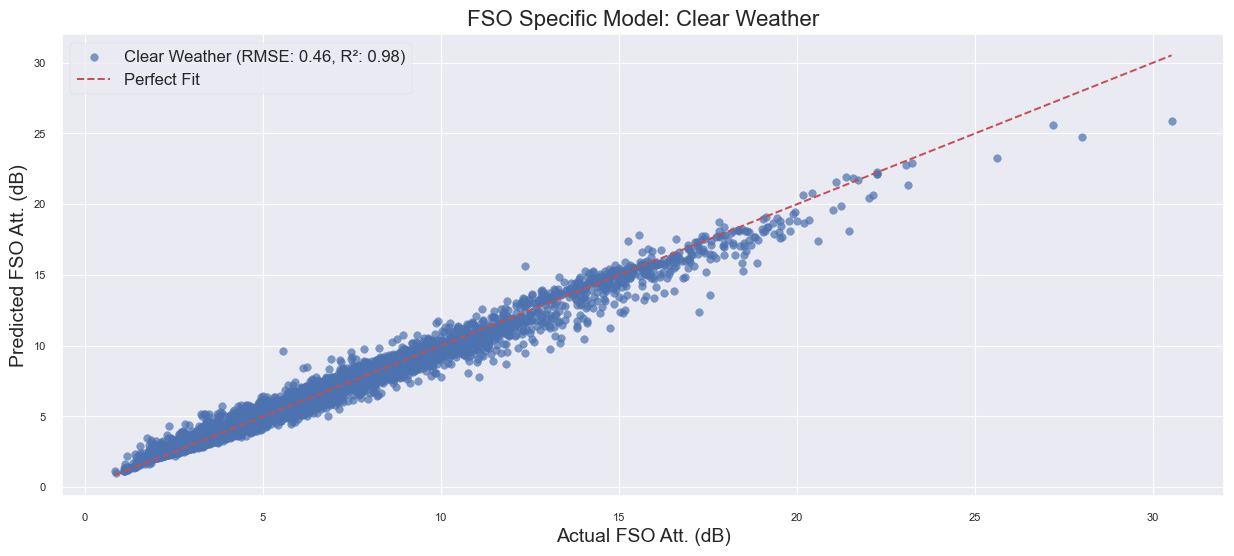

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Specific Model: Dust Storm - RMSE: 1.5737, R²: 0.9548
Plots saved to Figure/Evaluation/specific_FSO_Dust Storm_randomforest.eps and Figure/Evaluation/specific_FSO_Dust Storm_randomforest.jpg


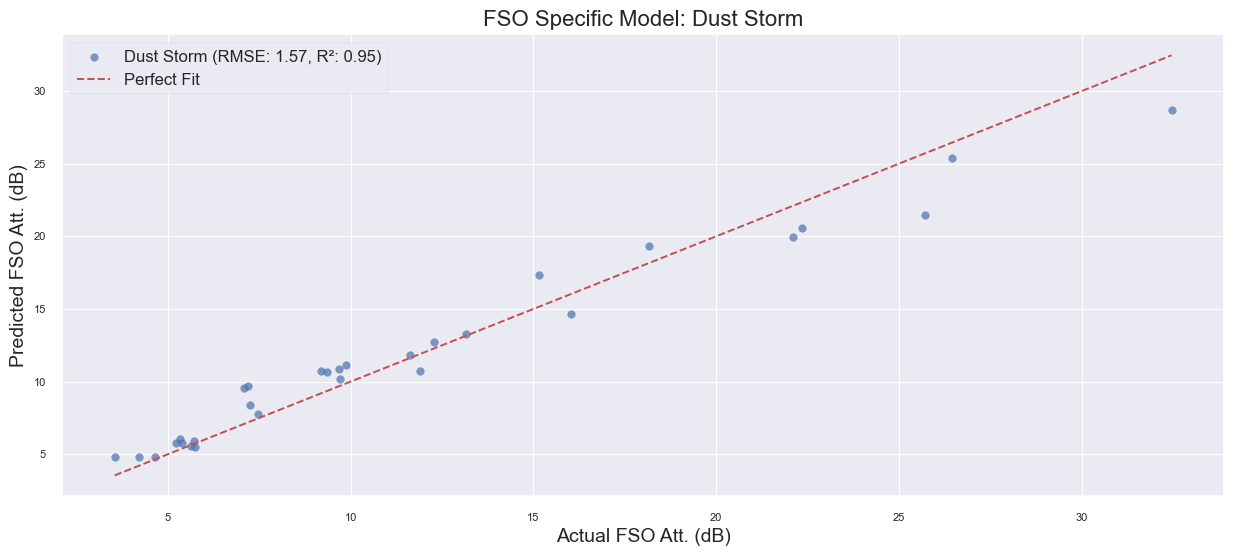

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Specific Model: Fog - RMSE: 0.3250, R²: 0.9944
Plots saved to Figure/Evaluation/specific_FSO_Fog_randomforest.eps and Figure/Evaluation/specific_FSO_Fog_randomforest.jpg


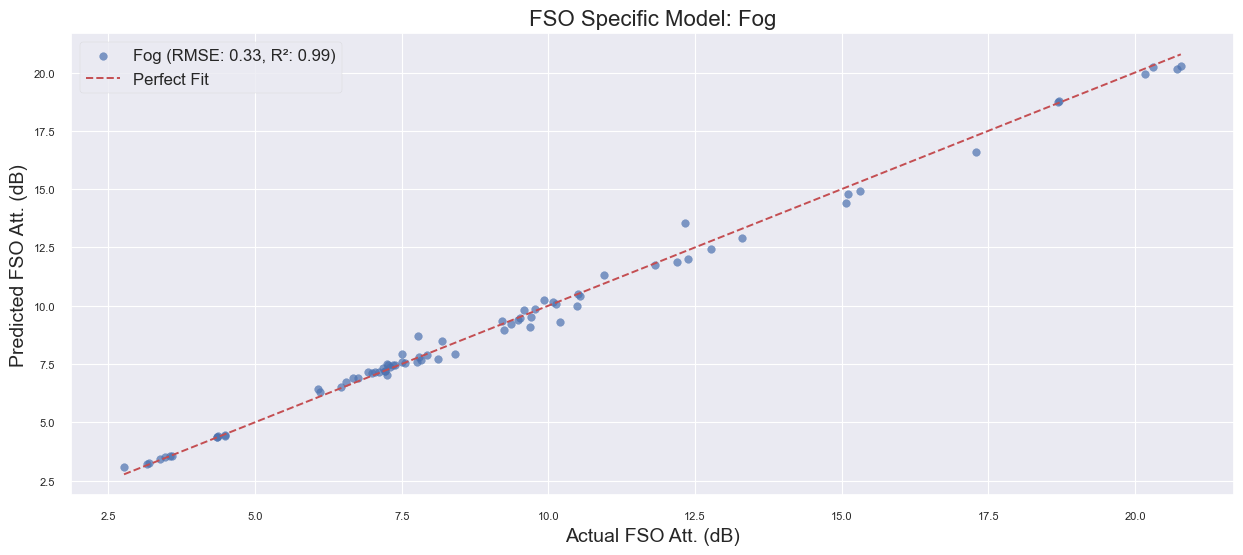

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Specific Model: Drizzle - RMSE: 0.4506, R²: 0.9835
Plots saved to Figure/Evaluation/specific_FSO_Drizzle_randomforest.eps and Figure/Evaluation/specific_FSO_Drizzle_randomforest.jpg


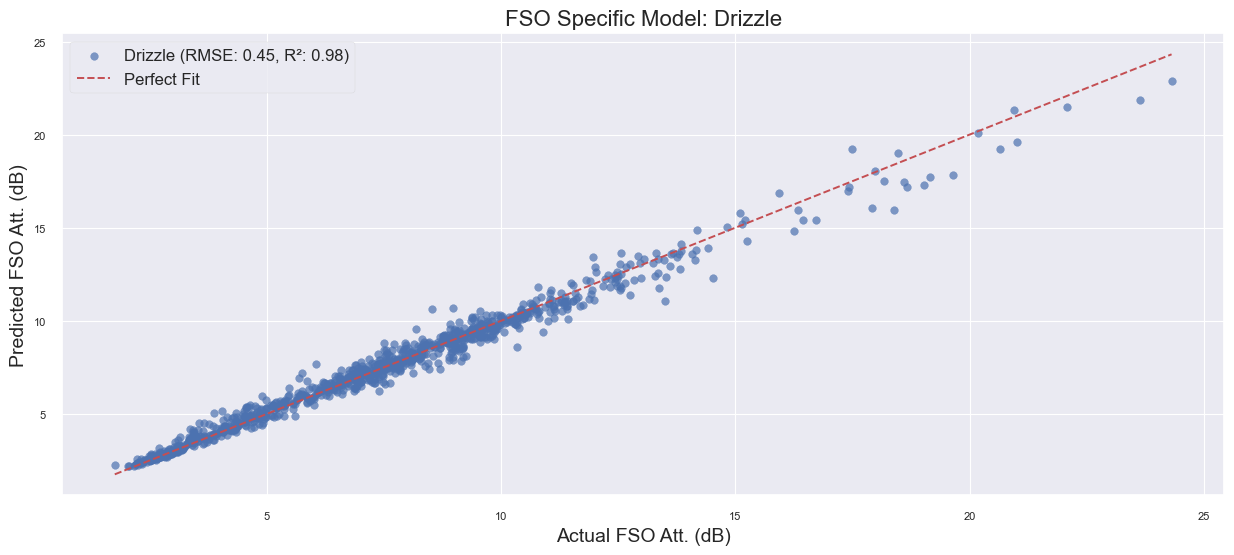

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Specific Model: Rain - RMSE: 0.5204, R²: 0.9846
Plots saved to Figure/Evaluation/specific_FSO_Rain_randomforest.eps and Figure/Evaluation/specific_FSO_Rain_randomforest.jpg


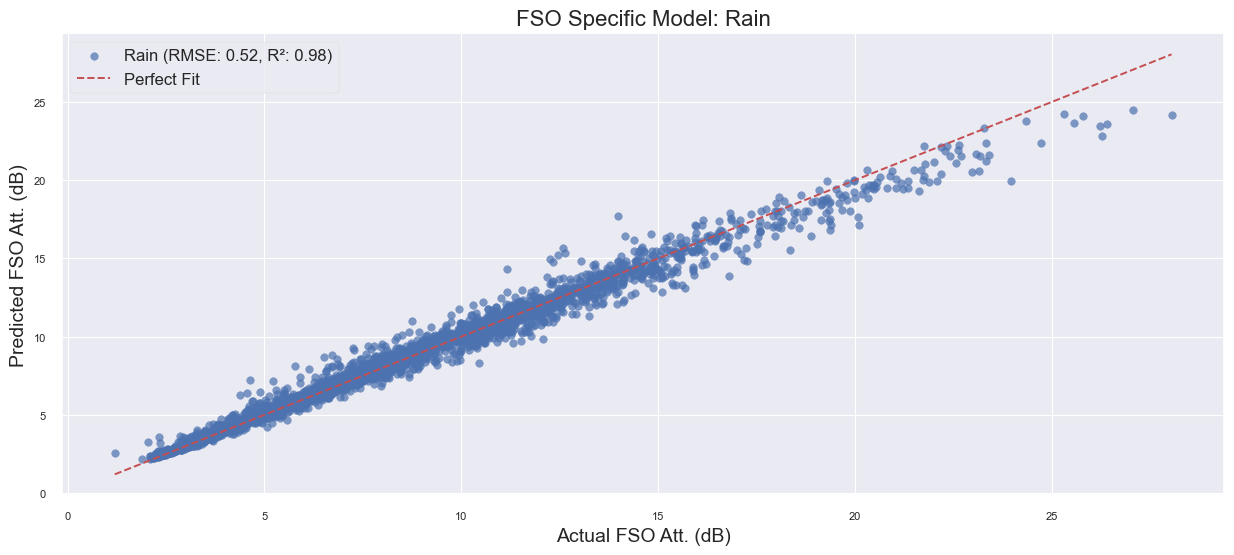

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Specific Model: Snow - RMSE: 0.7271, R²: 0.9781
Plots saved to Figure/Evaluation/specific_FSO_Snow_randomforest.eps and Figure/Evaluation/specific_FSO_Snow_randomforest.jpg


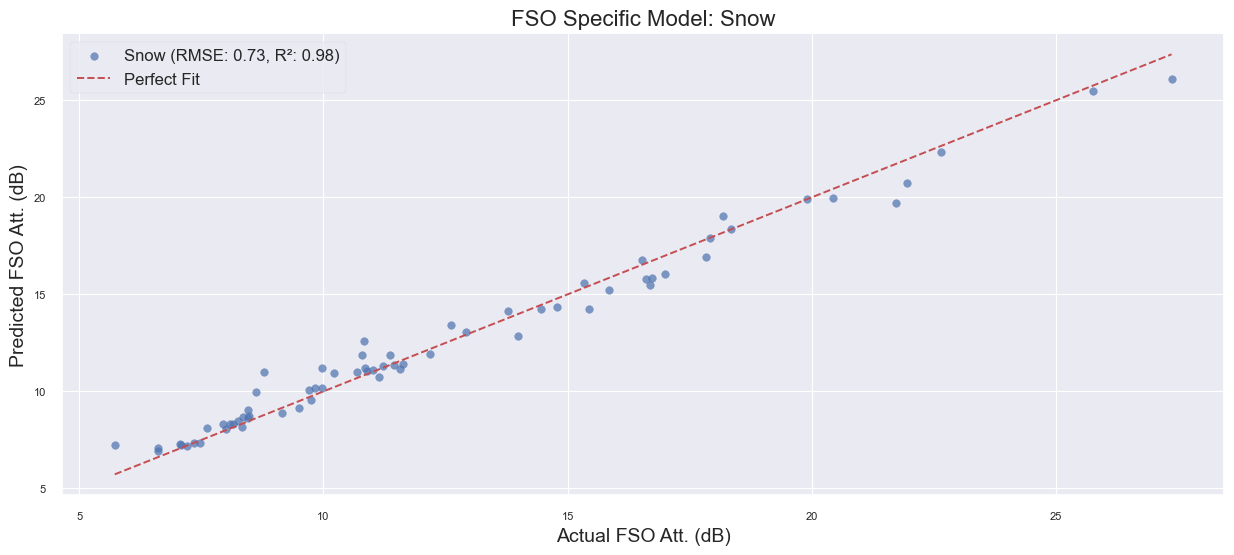

FSO Specific Model: Showers - RMSE: 0.7154, R²: 0.9713


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Plots saved to Figure/Evaluation/specific_FSO_Showers_randomforest.eps and Figure/Evaluation/specific_FSO_Showers_randomforest.jpg


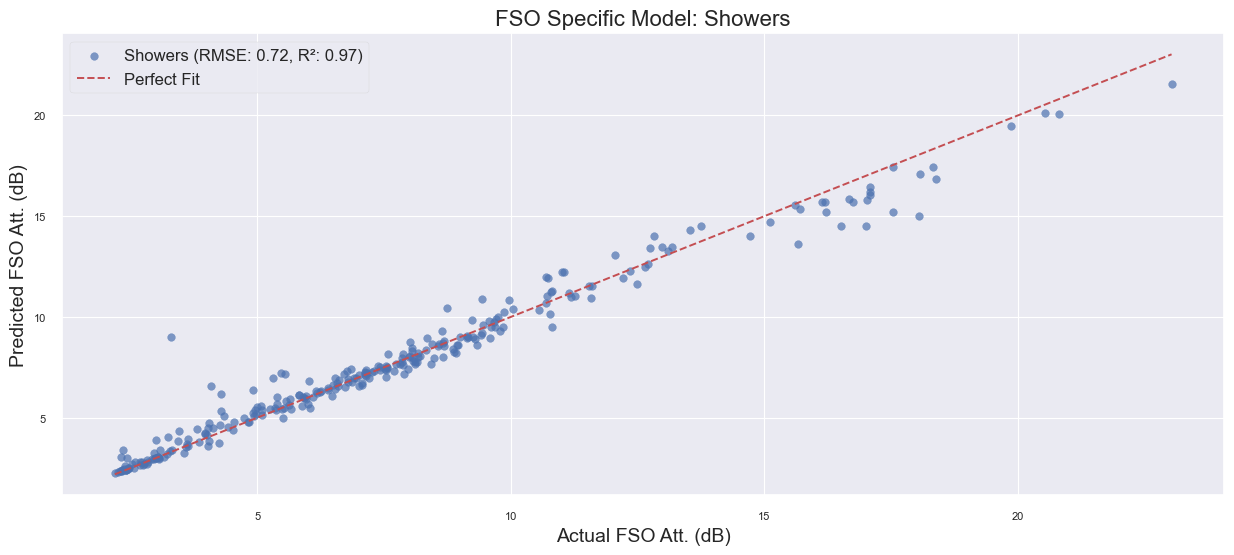

In [12]:
# Evaluate FSO Specific models on their corresponding validation sets
specific_fso_results = evaluate_specific_models(specific_fso_models, fso_val_files, y_fso_val_files, "FSO")

**For RF Attenuation**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Specific Model: Clear Weather - RMSE: 0.2139, R²: 0.9931
Plots saved to Figure/Evaluation/specific_RF_Clear Weather_randomforest.eps and Figure/Evaluation/specific_RF_Clear Weather_randomforest.jpg


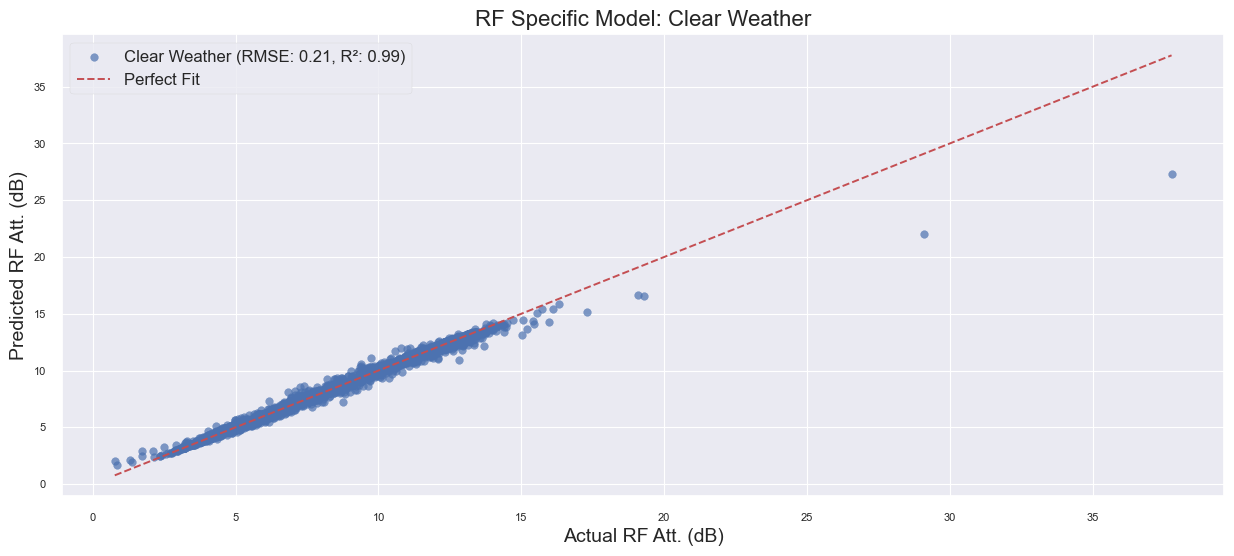

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Specific Model: Dust Storm - RMSE: 0.3463, R²: 0.9883
Plots saved to Figure/Evaluation/specific_RF_Dust Storm_randomforest.eps and Figure/Evaluation/specific_RF_Dust Storm_randomforest.jpg


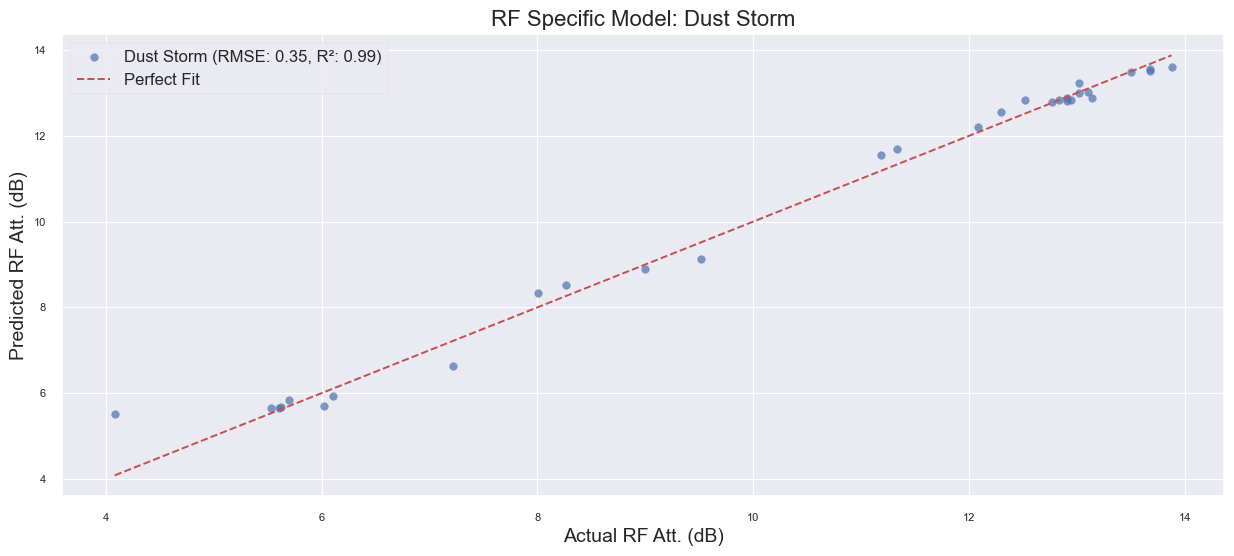

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Specific Model: Fog - RMSE: 0.3267, R²: 0.9755
Plots saved to Figure/Evaluation/specific_RF_Fog_randomforest.eps and Figure/Evaluation/specific_RF_Fog_randomforest.jpg


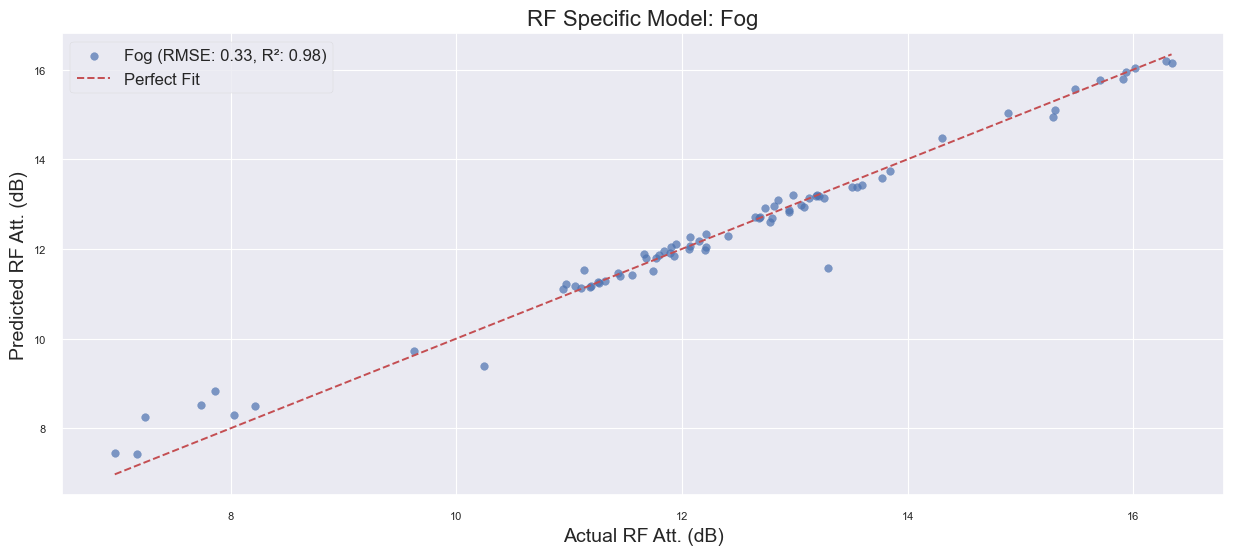

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Specific Model: Drizzle - RMSE: 0.3229, R²: 0.9879
Plots saved to Figure/Evaluation/specific_RF_Drizzle_randomforest.eps and Figure/Evaluation/specific_RF_Drizzle_randomforest.jpg


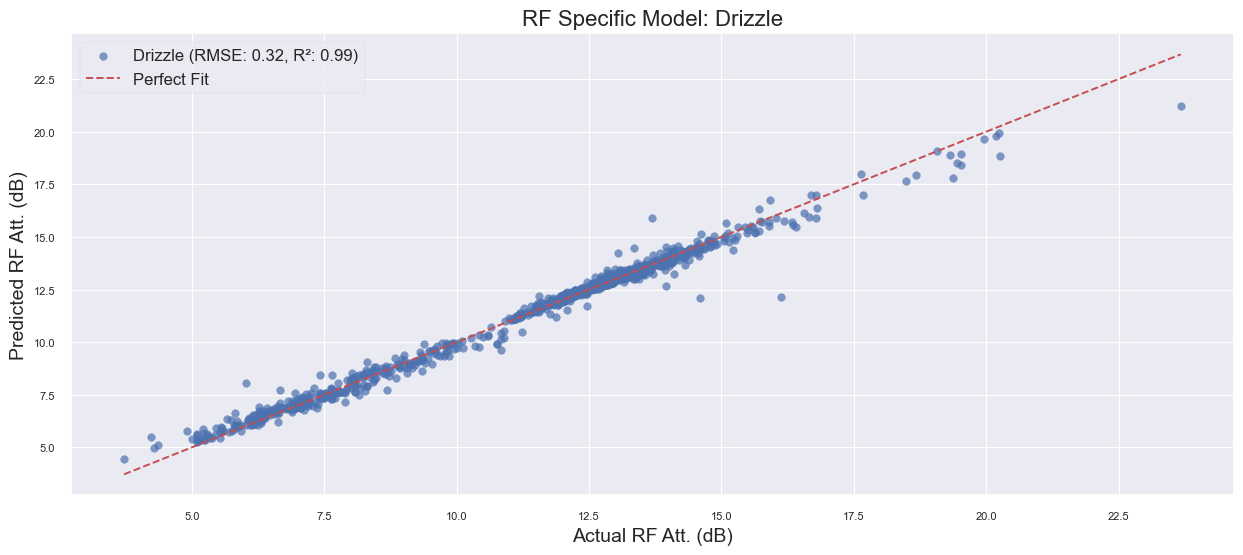

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Specific Model: Rain - RMSE: 0.4453, R²: 0.9880
Plots saved to Figure/Evaluation/specific_RF_Rain_randomforest.eps and Figure/Evaluation/specific_RF_Rain_randomforest.jpg


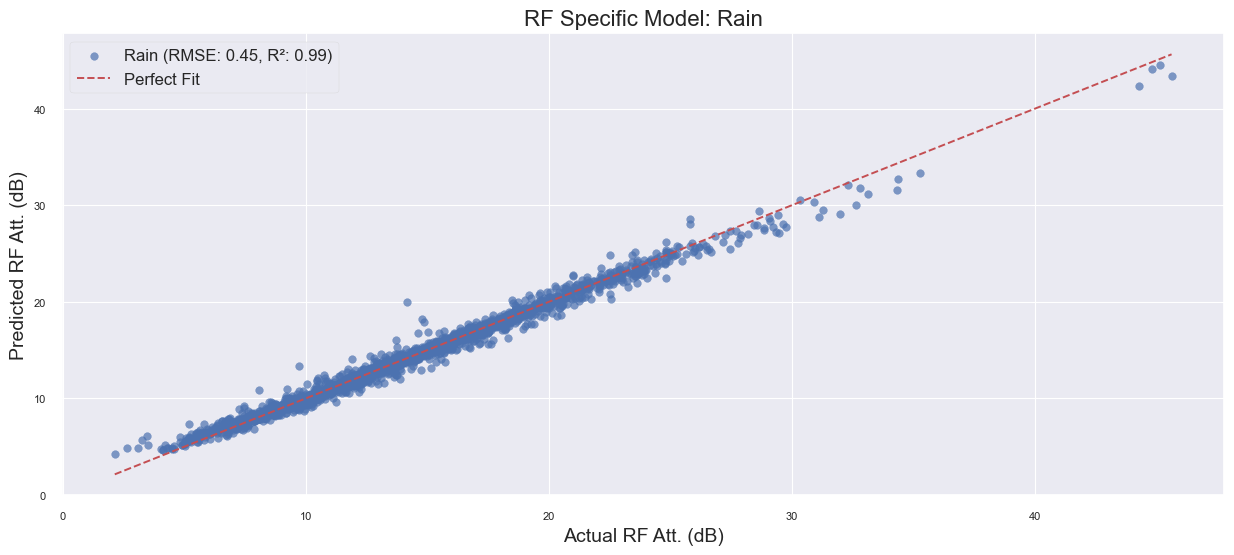

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Specific Model: Snow - RMSE: 0.2504, R²: 0.9692
Plots saved to Figure/Evaluation/specific_RF_Snow_randomforest.eps and Figure/Evaluation/specific_RF_Snow_randomforest.jpg


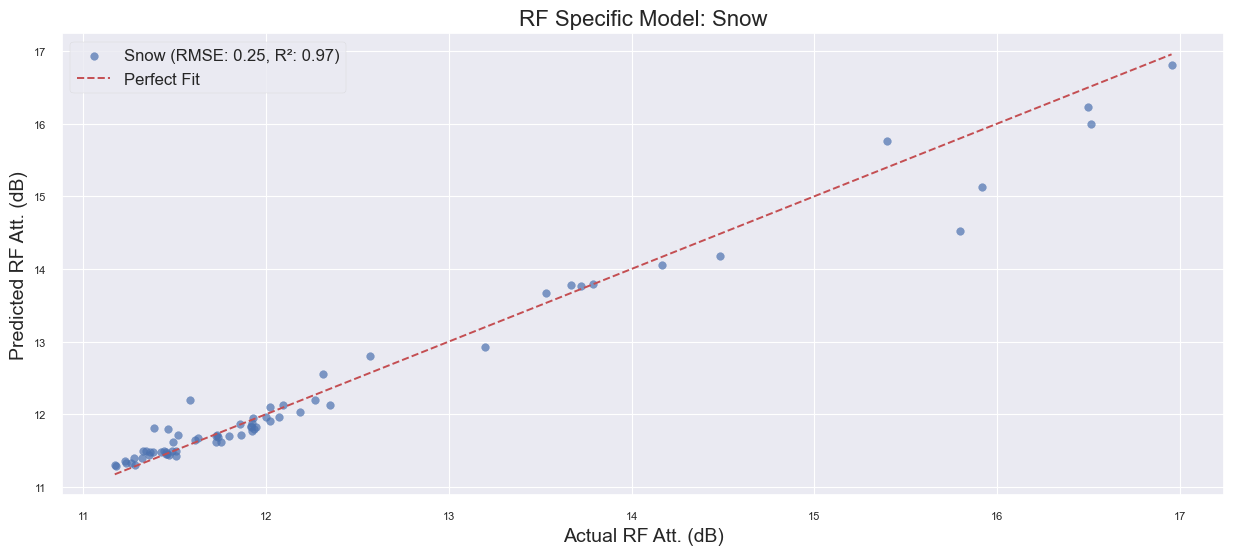

RF Specific Model: Showers - RMSE: 0.7326, R²: 0.9503


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Plots saved to Figure/Evaluation/specific_RF_Showers_randomforest.eps and Figure/Evaluation/specific_RF_Showers_randomforest.jpg


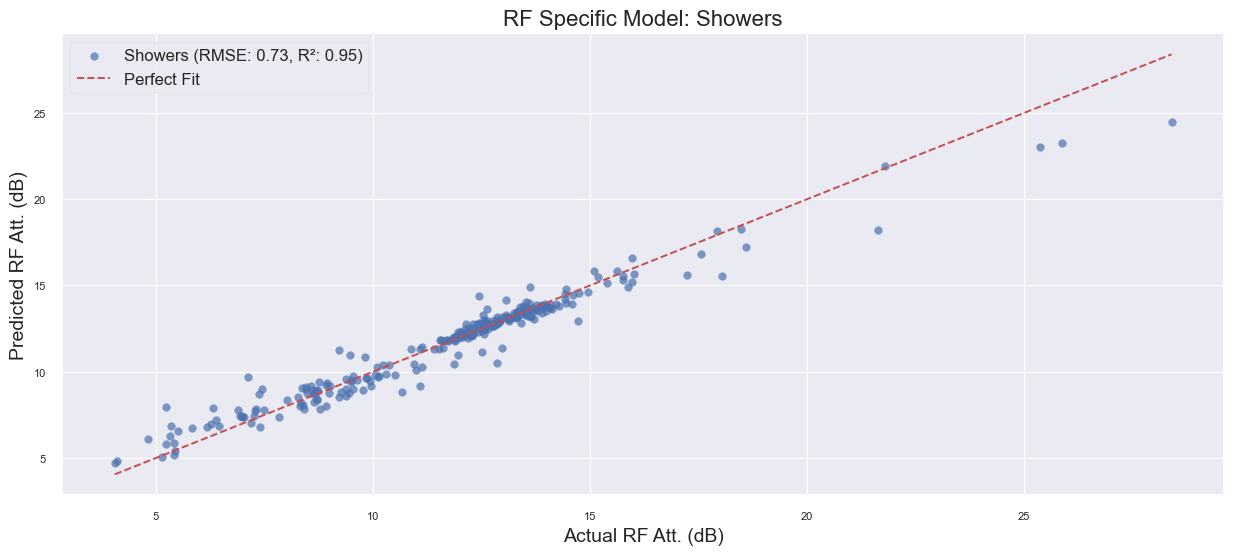

In [13]:
# Evaluate RF Specific models on their corresponding validation sets
specific_rf_results = evaluate_specific_models(specific_rf_models, rf_val_files, y_rf_val_files, "RF")

**(4) Validation Set Evaluation for the Generic Model**

In [14]:
# Define the paths to the validation datasets for FSO and RF
fso_gv_files = [
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Generic.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Specific0.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Specific3.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Specific4.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Specific5.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Specific6.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Specific7.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_FSO_Specific8.csv"
]



rf_gv_files = [
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Generic.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Specific0.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Specific3.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Specific4.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Specific5.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Specific6.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Specific7.csv",
    "Data/Splitting/Validation/Generic/X/updated_Generic_Feature_RF_Specific8.csv"
]


# Define paths for FSO and RF validation target variables
y_fso_gv_files = [
    "Data/Splitting/Validation/Generic/Y/y_val_FSO.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_0.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_3.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_4.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_5.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_6.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_7.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_FSO_SC_8.csv"
]


y_rf_gv_files = [
    "Data/Splitting/Validation/Generic/Y/y_val_RF.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_0.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_3.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_4.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_5.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_6.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_7.csv",
    "Data/Splitting/Validation/Specific/Y/val_y_RF_SC_8.csv"
]

In [15]:
# Function to evaluate a model on multiple validation sets
def evaluate_generic_model(generic_model, x_val_files, y_val_files, label, output_dir="Figure/Evaluation"):
    """
    Evaluate a generic Random Forest model on multiple validation sets.

    Parameters:
    - generic_model (dict): Dictionary containing the model information (e.g., best parameters).
    - x_val_files (list): List of file paths for validation feature datasets (X).
    - y_val_files (list): List of file paths for validation target datasets (y).
    - label (str): Label to identify the type of model (e.g., "FSO" or "RF").
    - output_dir (str): Directory to save evaluation plots (default is "Figure/Evaluation").

    Returns:
    - results (list): List of dictionaries containing evaluation results (RMSE and R²) for each validation set.
    """
    results = []

    # Ensure the output directory exists
    os.makedirs(output_dir, exist_ok=True)

    for x_val_file, y_val_file in zip(x_val_files, y_val_files):
        # Load validation data
        X_val = pd.read_csv(x_val_file)
        y_val = pd.read_csv(y_val_file).squeeze()

        # Initialize model with the best parameters
        best_params = generic_model['Best Params']
        model = RandomForestRegressor(random_state=42, **best_params)
        model.fit(X_val, y_val)  # Train model on the validation set

        # Predict on validation set
        y_pred = model.predict(X_val)

        # Calculate RMSE and R²
        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        r2 = r2_score(y_val, y_pred)

        # Extract model name from the file path

        # Extract model name from the file path
        # Example: "updated_Generic_Feature_FSO_Generic.csv" -> "Generic"
        # Example: "updated_Generic_Feature_FSO_Specific0.csv" -> "Specific0"
        file_name = os.path.basename(x_val_file)  # Extract the file name
        if "Generic" in file_name and "Specific" not in file_name:
            model_name = "Generic"
        elif "Specific" in file_name:
            model_name = file_name.split('_')[-1].split('.')[0]  
        else:
            model_name = "Unknown"

        model_name = weather_conditions.get(model_name, model_name)

        # Print results
        print(f"{label} Generic Model: {model_name} - RMSE: {rmse:.4f}, R²: {r2:.4f}")

        # Store results
        results.append({'Model': model_name, 'RMSE': rmse, 'R2': r2})

        # Plot the results
        plt.figure(figsize=(15, 6))
        plt.style.use('seaborn-v0_8-paper')

        plt.scatter(y_val, y_pred, label=f'{model_name} (RMSE: {rmse:.2f}, R²: {r2:.2f})', alpha=0.7)
        plt.plot([min(y_val), max(y_val)], [min(y_val), max(y_val)], 'r--', label='Perfect Fit')

        plt.xlabel(f"Actual {label} Att. (dB)", fontsize=14)
        plt.ylabel(f"Predicted {label} Att. (dB)", fontsize=14)
        plt.title(f"{label} Generic Model: {model_name}", fontsize=16)
        plt.legend(fontsize=12)
        plt.grid(True)

        # Save the plot in both .eps and .jpg formats
        eps_file = os.path.join(output_dir, f'Generic_{label}_{model_name}_randomforest.eps')
        jpg_file = os.path.join(output_dir, f'Generic_{label}_{model_name}_randomforest.jpg')
        plt.savefig(eps_file, format='eps')
        plt.savefig(jpg_file, format='jpg')
        print(f"Plots saved to {eps_file} and {jpg_file}")
        plt.show()

    return results

**For FSO Attenuation**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Generic - RMSE: 0.4677, R²: 0.9852
Plots saved to Figure/Evaluation/Generic_FSO_Generic_randomforest.eps and Figure/Evaluation/Generic_FSO_Generic_randomforest.jpg


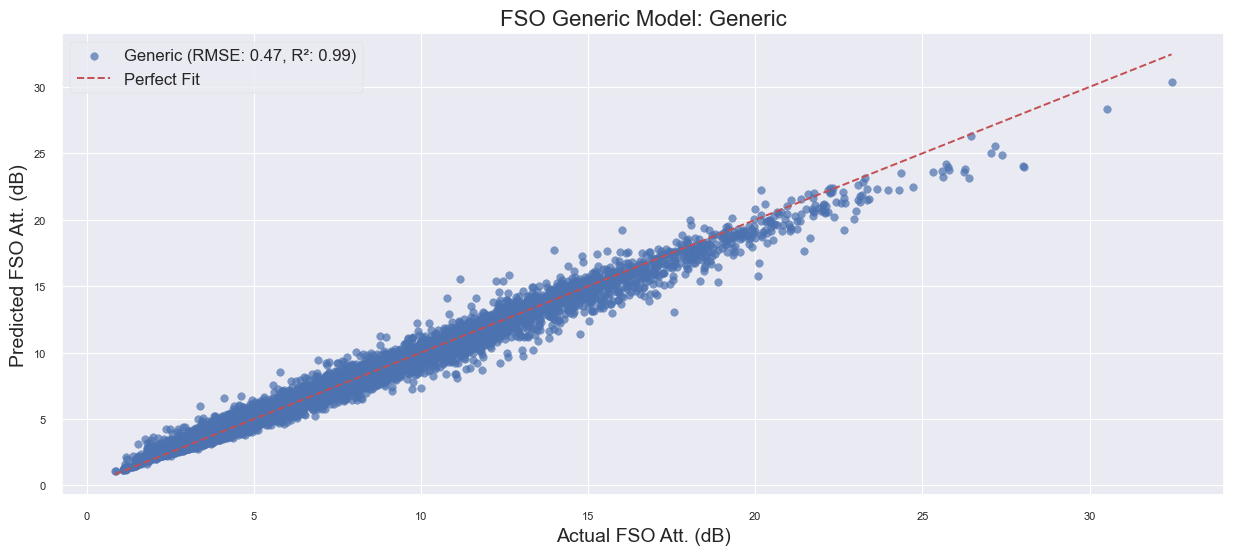

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Clear Weather - RMSE: 0.4427, R²: 0.9838
Plots saved to Figure/Evaluation/Generic_FSO_Clear Weather_randomforest.eps and Figure/Evaluation/Generic_FSO_Clear Weather_randomforest.jpg


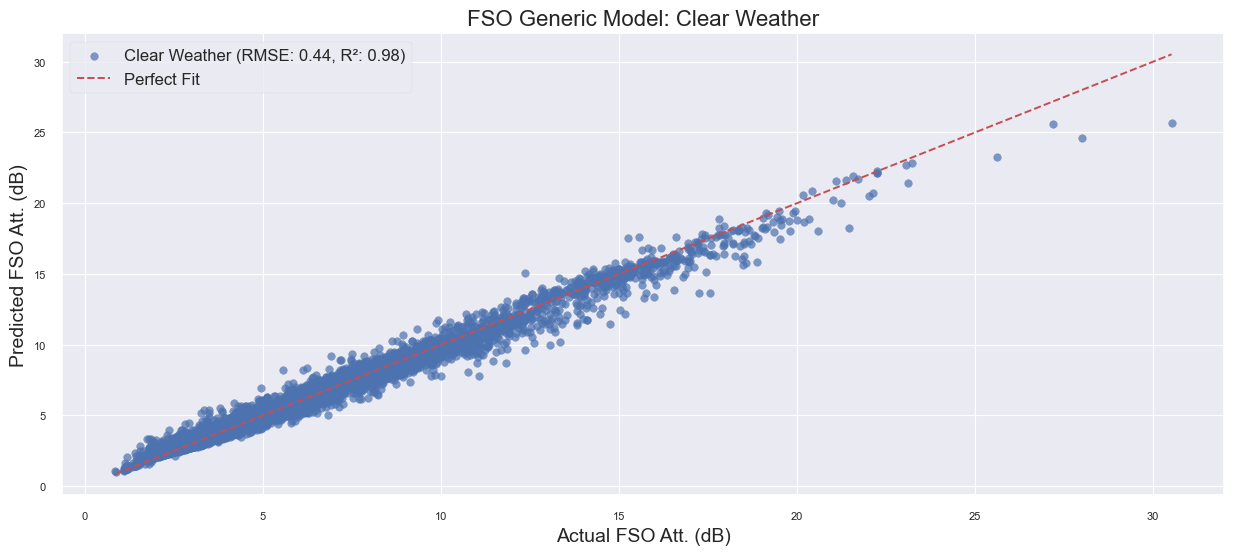

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Dust Storm - RMSE: 1.9311, R²: 0.9320
Plots saved to Figure/Evaluation/Generic_FSO_Dust Storm_randomforest.eps and Figure/Evaluation/Generic_FSO_Dust Storm_randomforest.jpg


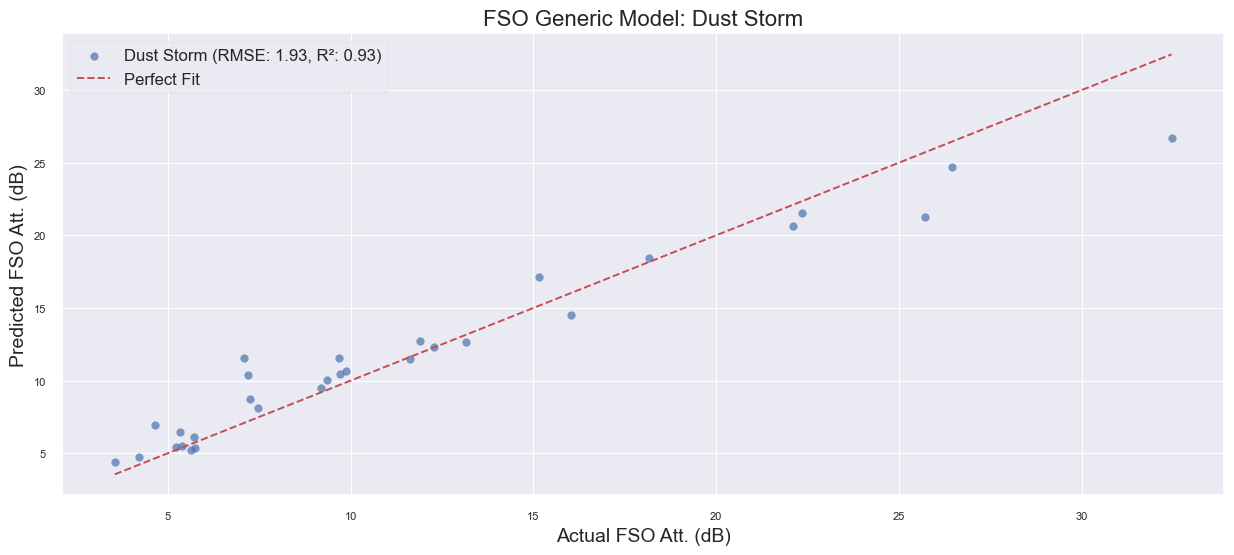

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Fog - RMSE: 0.3572, R²: 0.9933
Plots saved to Figure/Evaluation/Generic_FSO_Fog_randomforest.eps and Figure/Evaluation/Generic_FSO_Fog_randomforest.jpg


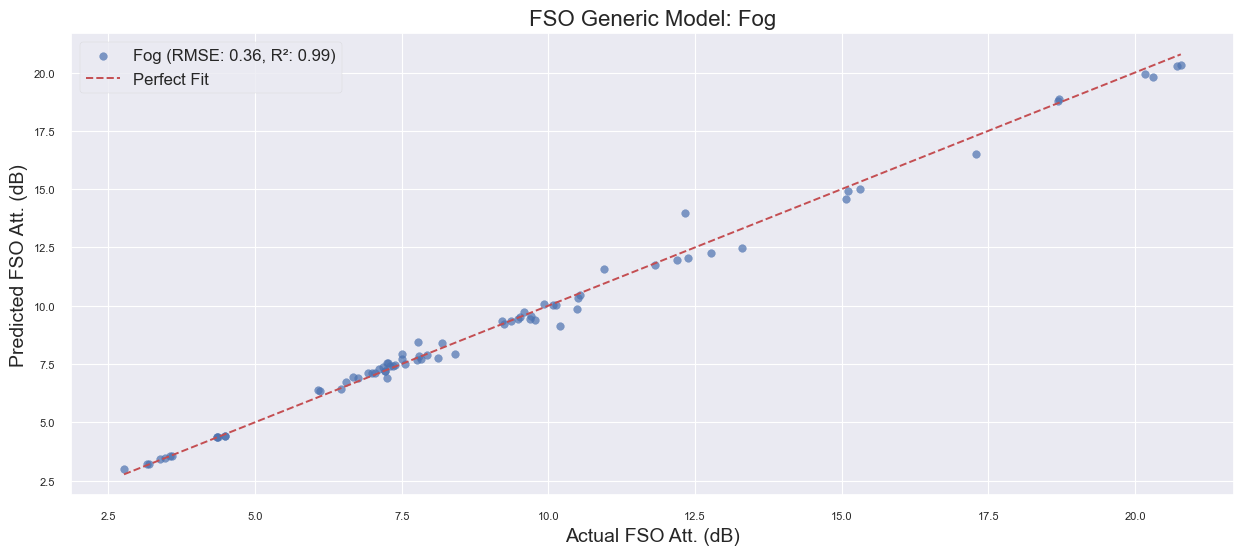

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Drizzle - RMSE: 0.4551, R²: 0.9832
Plots saved to Figure/Evaluation/Generic_FSO_Drizzle_randomforest.eps and Figure/Evaluation/Generic_FSO_Drizzle_randomforest.jpg


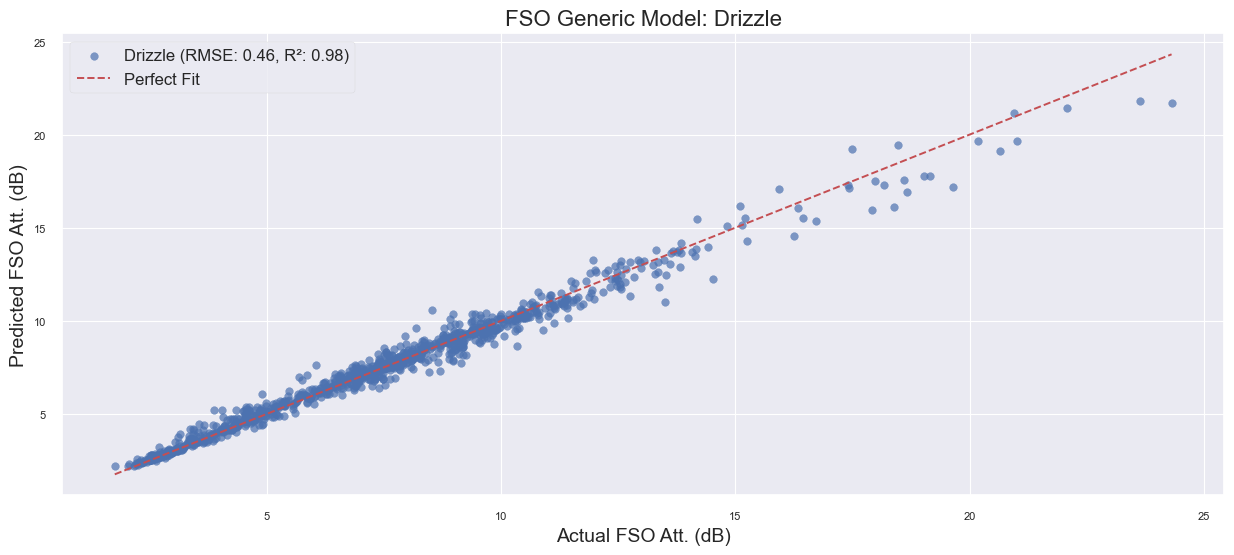

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Rain - RMSE: 0.5195, R²: 0.9846
Plots saved to Figure/Evaluation/Generic_FSO_Rain_randomforest.eps and Figure/Evaluation/Generic_FSO_Rain_randomforest.jpg


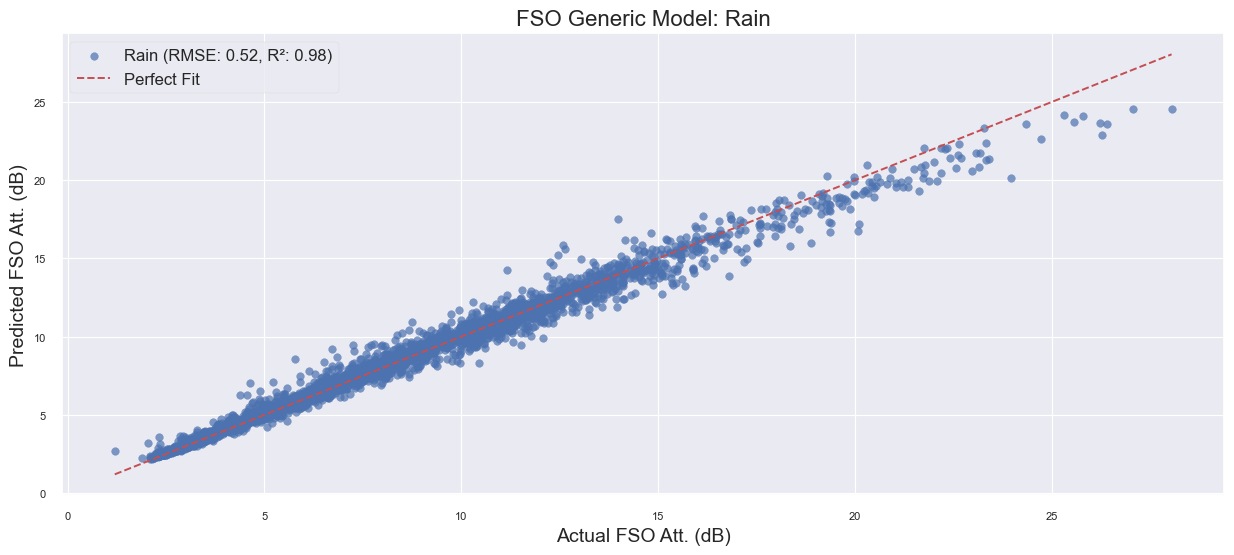

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Snow - RMSE: 0.7917, R²: 0.9740
Plots saved to Figure/Evaluation/Generic_FSO_Snow_randomforest.eps and Figure/Evaluation/Generic_FSO_Snow_randomforest.jpg


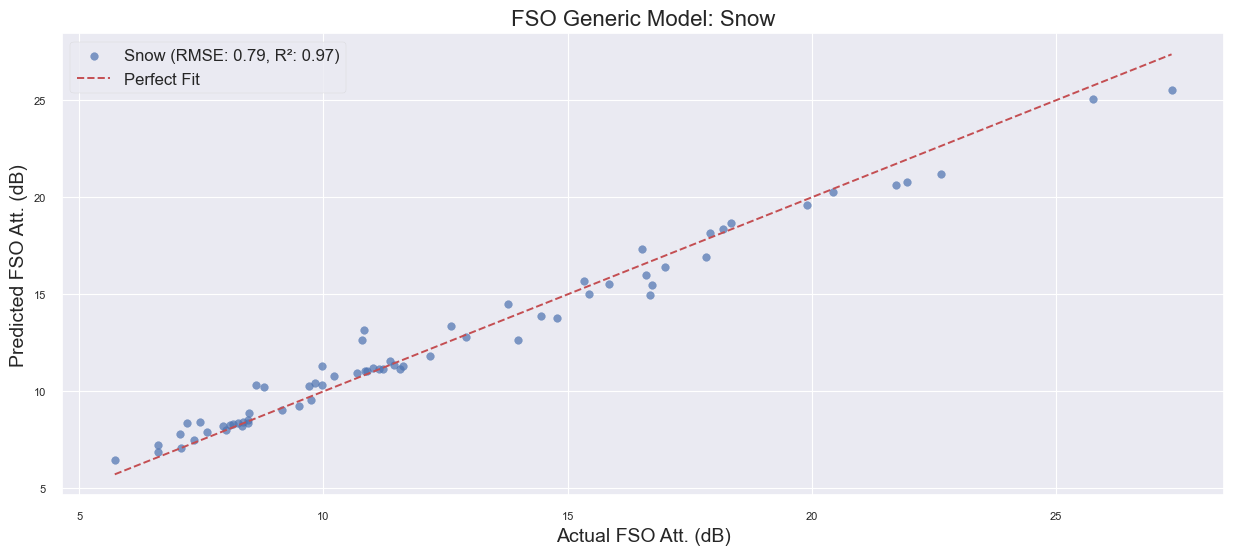

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


FSO Generic Model: Showers - RMSE: 0.6452, R²: 0.9767
Plots saved to Figure/Evaluation/Generic_FSO_Showers_randomforest.eps and Figure/Evaluation/Generic_FSO_Showers_randomforest.jpg


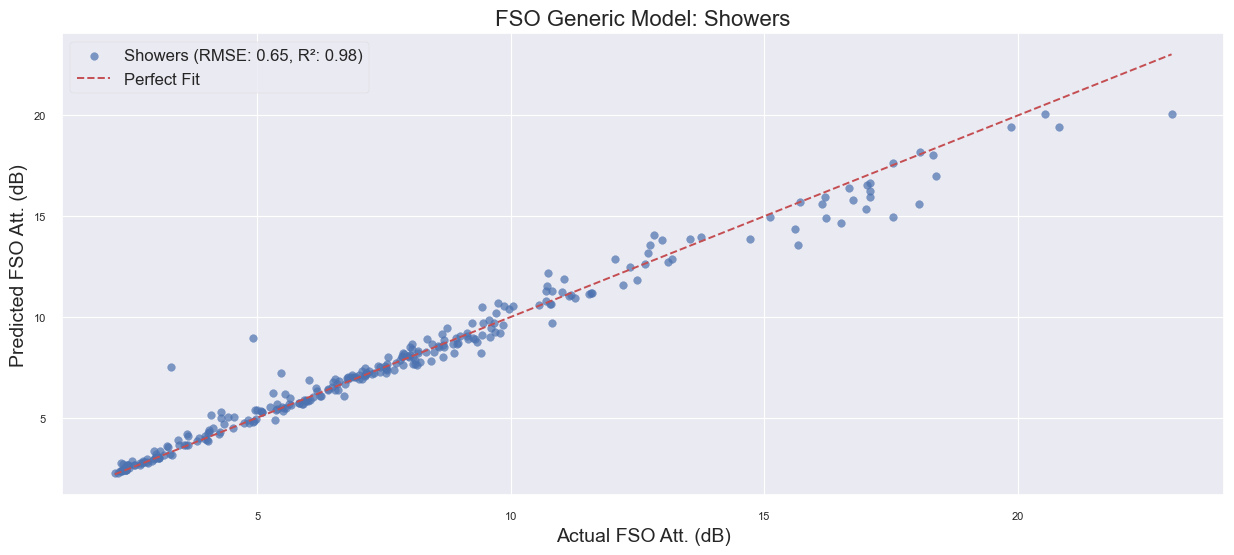

In [16]:
# Evaluate the FSO Generic model on all validation sets
generic_fso_results = evaluate_generic_model(generic_fso_model, fso_gv_files, y_fso_gv_files, "FSO")

**For RF Attenuation**

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Generic - RMSE: 0.3369, R²: 0.9906
Plots saved to Figure/Evaluation/Generic_RF_Generic_randomforest.eps and Figure/Evaluation/Generic_RF_Generic_randomforest.jpg


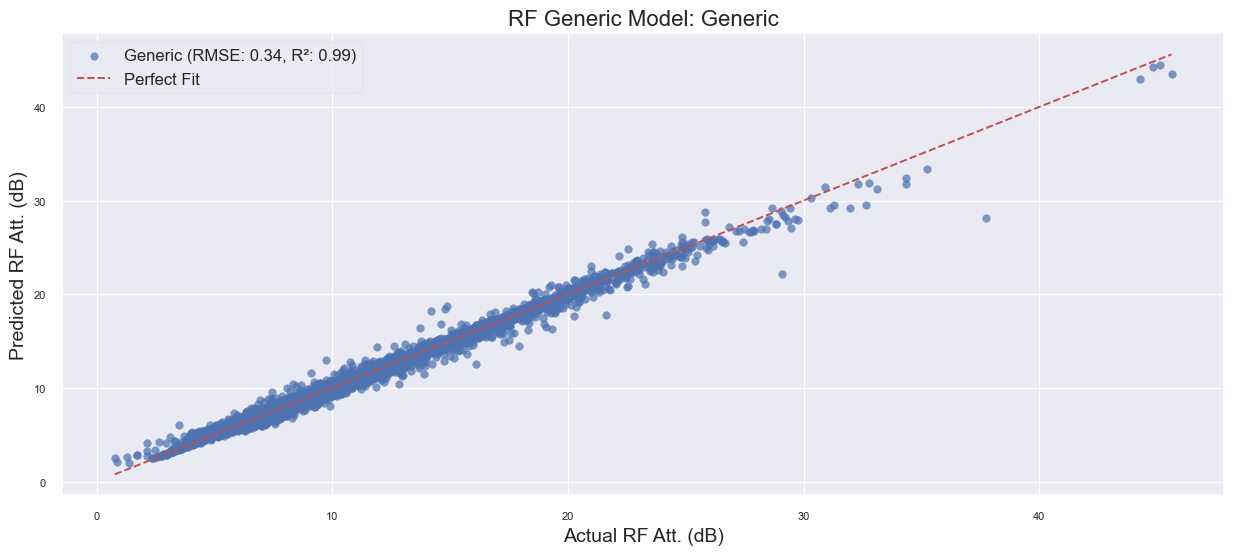

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Clear Weather - RMSE: 0.2624, R²: 0.9897
Plots saved to Figure/Evaluation/Generic_RF_Clear Weather_randomforest.eps and Figure/Evaluation/Generic_RF_Clear Weather_randomforest.jpg


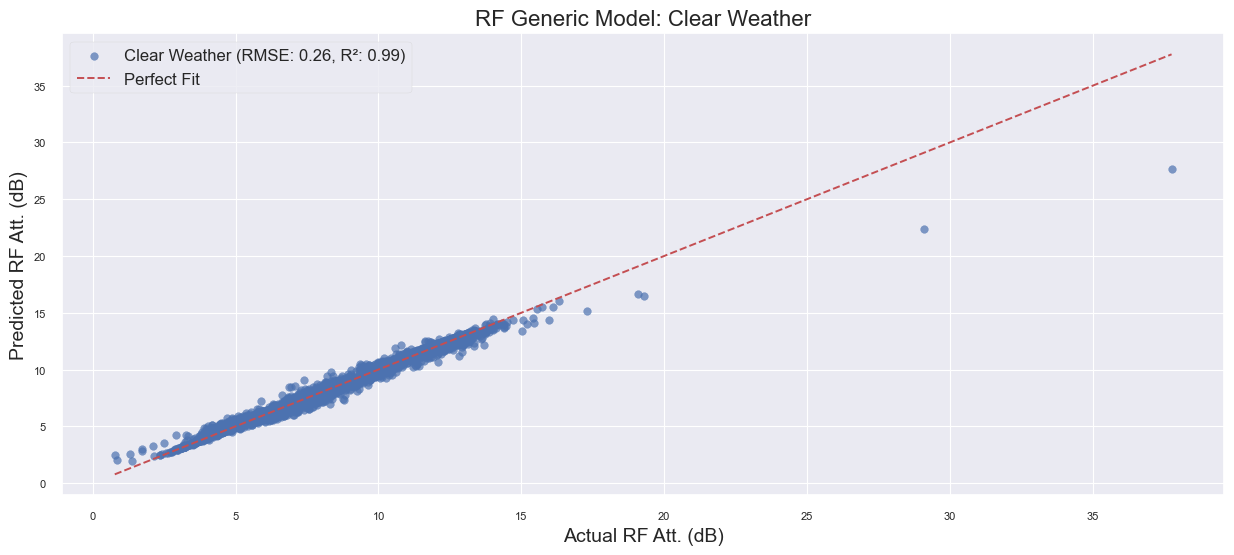

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Dust Storm - RMSE: 0.3859, R²: 0.9854
Plots saved to Figure/Evaluation/Generic_RF_Dust Storm_randomforest.eps and Figure/Evaluation/Generic_RF_Dust Storm_randomforest.jpg


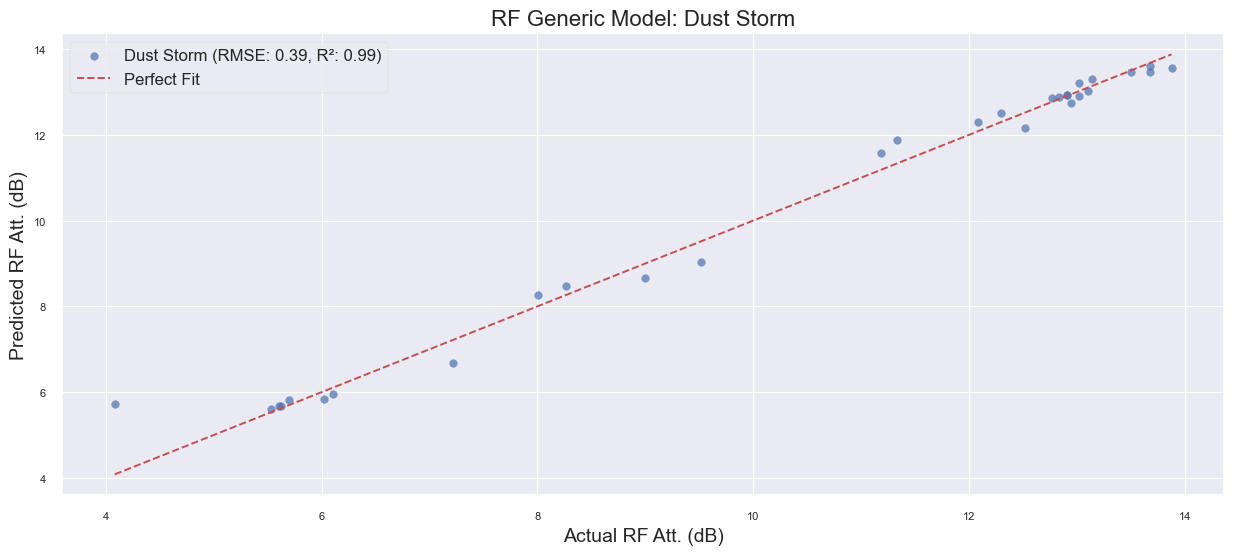

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Fog - RMSE: 0.3498, R²: 0.9719
Plots saved to Figure/Evaluation/Generic_RF_Fog_randomforest.eps and Figure/Evaluation/Generic_RF_Fog_randomforest.jpg


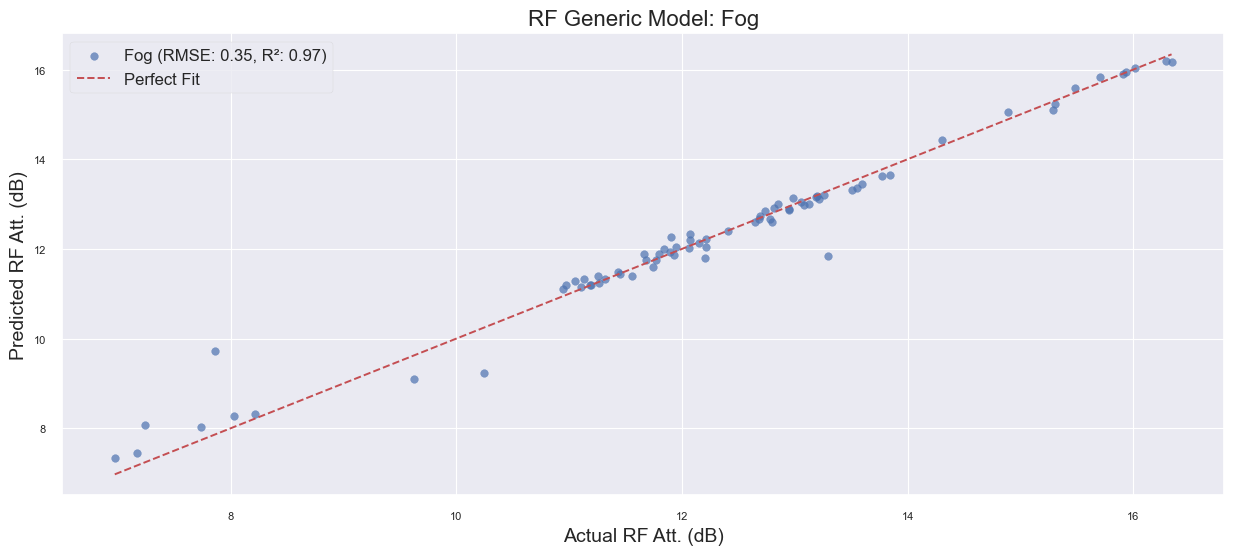

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Drizzle - RMSE: 0.3376, R²: 0.9867
Plots saved to Figure/Evaluation/Generic_RF_Drizzle_randomforest.eps and Figure/Evaluation/Generic_RF_Drizzle_randomforest.jpg


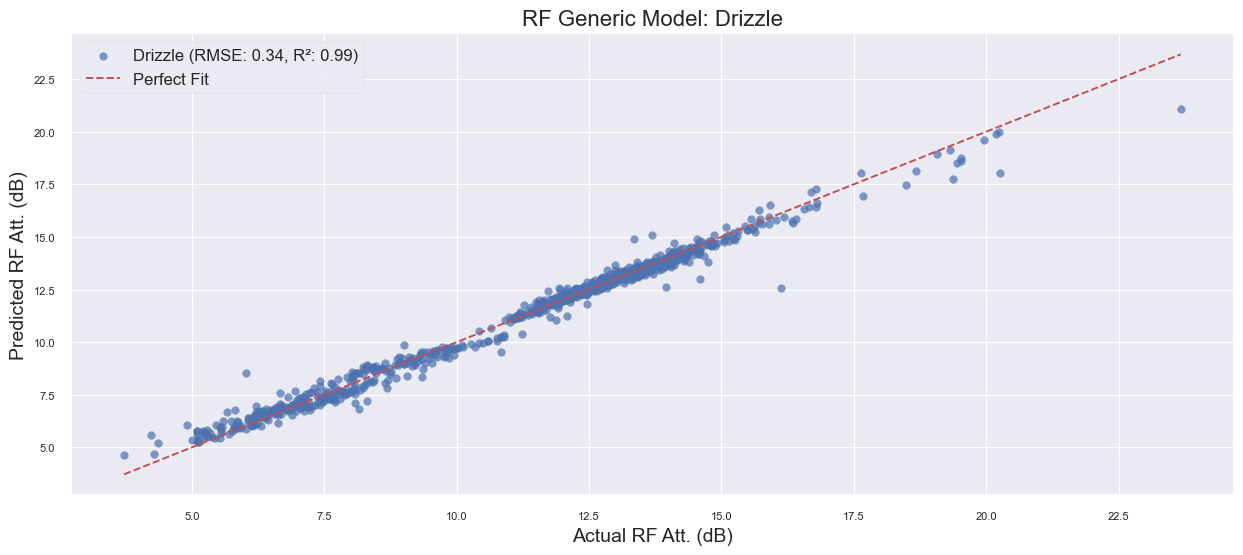

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Rain - RMSE: 0.4456, R²: 0.9880
Plots saved to Figure/Evaluation/Generic_RF_Rain_randomforest.eps and Figure/Evaluation/Generic_RF_Rain_randomforest.jpg


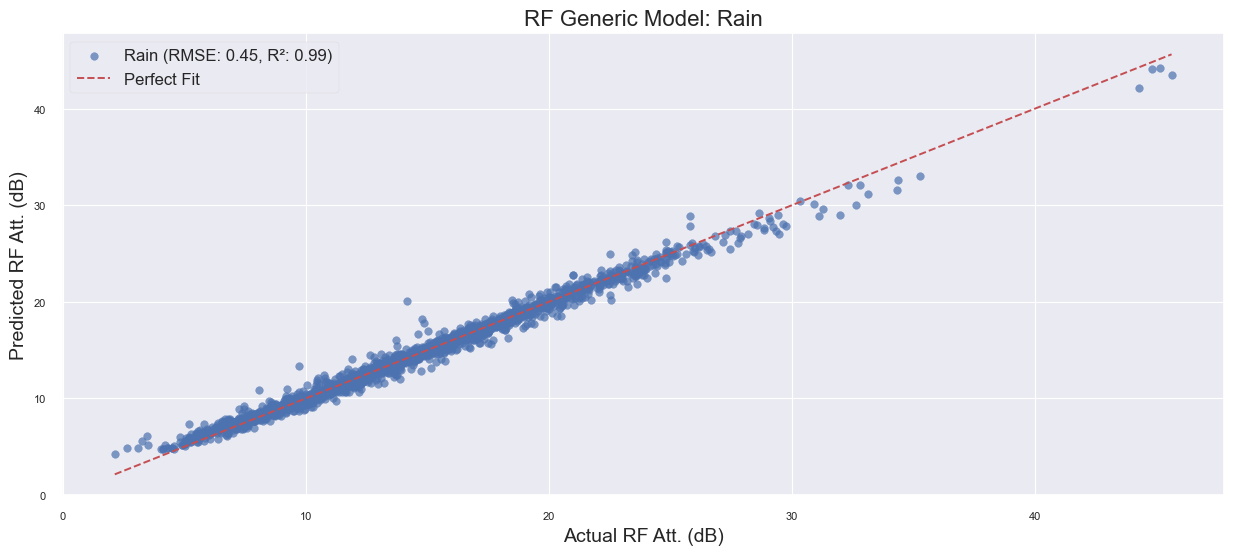

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Snow - RMSE: 0.2559, R²: 0.9678
Plots saved to Figure/Evaluation/Generic_RF_Snow_randomforest.eps and Figure/Evaluation/Generic_RF_Snow_randomforest.jpg


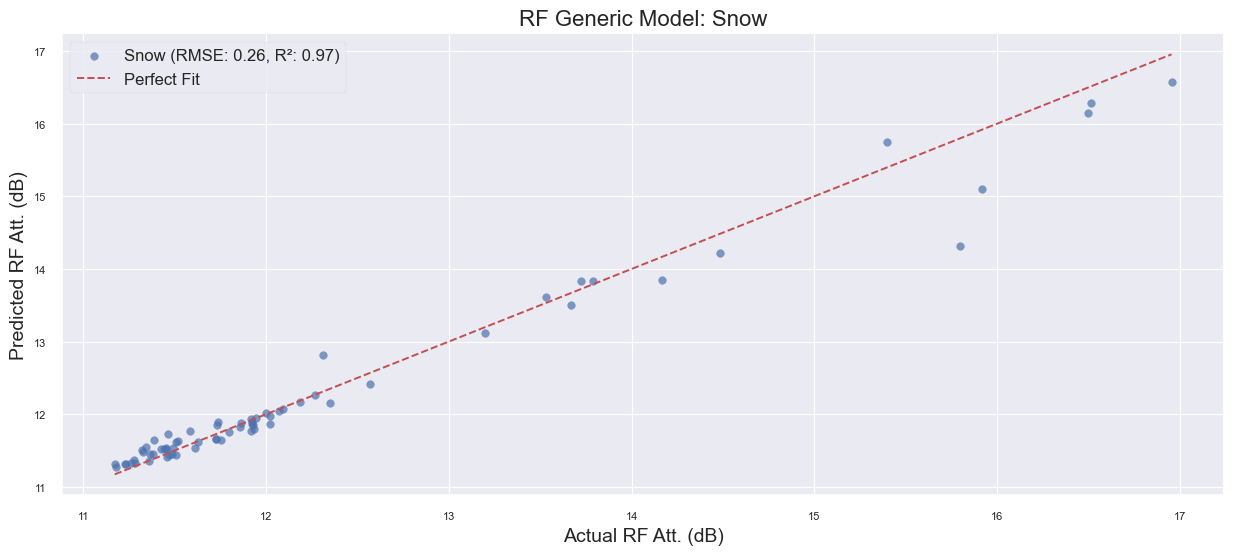

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


RF Generic Model: Showers - RMSE: 0.5339, R²: 0.9736
Plots saved to Figure/Evaluation/Generic_RF_Showers_randomforest.eps and Figure/Evaluation/Generic_RF_Showers_randomforest.jpg


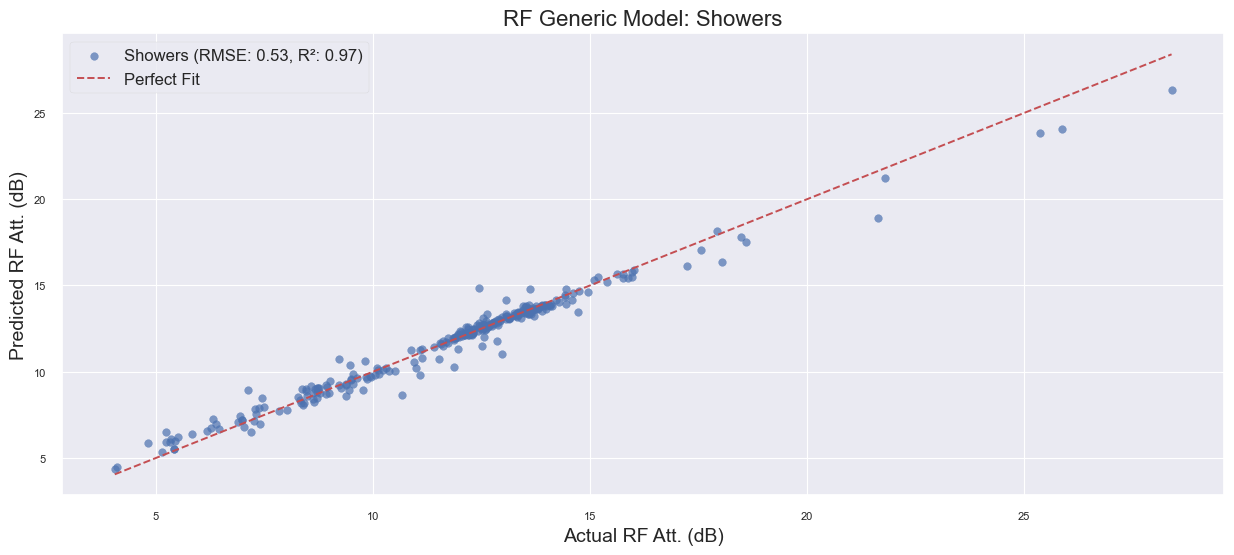

In [17]:
# Evaluate the RF Generic model on all validation sets
generic_rf_results = evaluate_generic_model(generic_rf_model, rf_gv_files, y_rf_gv_files, "RF")

**(5) Comparison of RMSE and $R^2$ between Specific and Generic Models**

In [18]:
# Extract data for plotting
weather_conditions = [result['Model'] for result in specific_fso_results]
weather_conditions

['Clear Weather', 'Dust Storm', 'Fog', 'Drizzle', 'Rain', 'Snow', 'Showers']

In [19]:
# Extract RMSE and R² values for FSO and RF from both specific and generic results

# FSO RMSE
fso_specific_rmse = [result['RMSE'] for result in specific_fso_results]
fso_generic_rmse = [result['RMSE'] for result in generic_fso_results]
fso_generic_rmse_all_weather = fso_generic_rmse[:1]  # RMSE for all-weather model
fso_generic_rmse_by_SC = fso_generic_rmse[1:]       # RMSE for specific SYNOP codes

# RF RMSE
rf_specific_rmse = [result['RMSE'] for result in specific_rf_results]
rf_generic_rmse = [result['RMSE'] for result in generic_rf_results]
rf_generic_rmse_all_weather = rf_generic_rmse[:1]   # RMSE for all-weather model
rf_generic_rmse_by_SC = rf_generic_rmse[1:]         # RMSE for specific SYNOP codes

# FSO R²
fso_specific_r2 = [result['R2'] for result in specific_fso_results]
fso_generic_r2 = [result['R2'] for result in generic_fso_results]
fso_generic_r2_all_weather = fso_generic_r2[:1]     # R² for all-weather model
fso_generic_r2_by_SC = fso_generic_r2[1:]           # R² for specific SYNOP codes

# RF R²
rf_specific_r2 = [result['R2'] for result in specific_rf_results]
rf_generic_r2 = [result['R2'] for result in generic_rf_results]
rf_generic_r2_all_weather = rf_generic_r2[:1]       # R² for all-weather model
rf_generic_r2_by_SC = rf_generic_r2[1:]             # R² for specific SYNOP codes

RMSE plot saved to Figure/Evaluation/Compare_RMSE_randomforest.eps and Figure/Evaluation/Compare_RMSE_randomforest.jpg


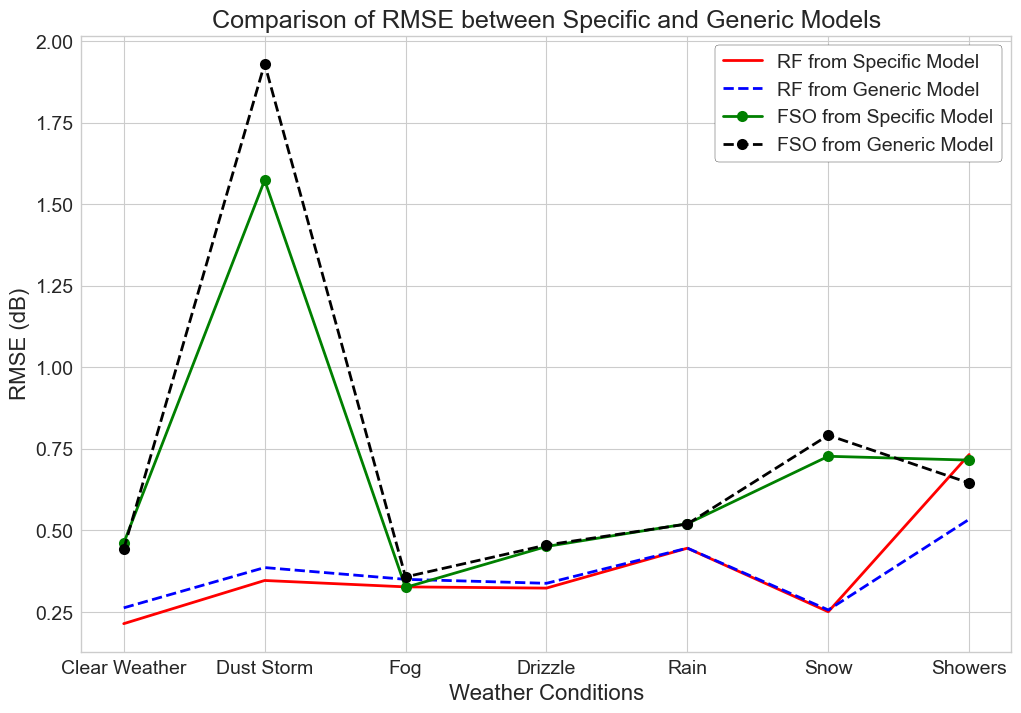

R² plot saved to Figure/Evaluation/Compare_R2_randomforest.eps and Figure/Evaluation/Compare_R2_randomforest.jpg


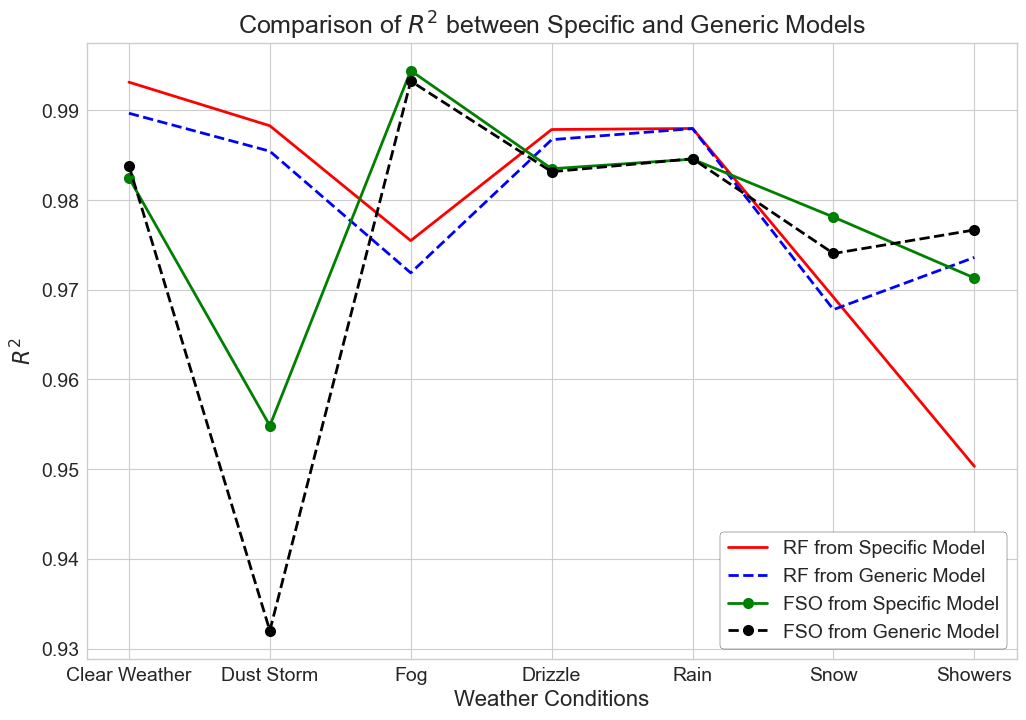

In [20]:
# Define output directories
output_dir = 'Figure/Evaluation'
# Ensure the directories exist
os.makedirs(output_dir, exist_ok=True)
# Set a style for white background with black grid
plt.style.use('seaborn-v0_8-whitegrid')

# Plot RMSE
plt.figure(figsize=(12, 8))
plt.plot(weather_conditions, rf_specific_rmse, 'x-', color='red', label="RF from Specific Model", markersize=8, linewidth=2)
plt.plot(weather_conditions, rf_generic_rmse_by_SC, 'x--', color='blue', label="RF from Generic Model", markersize=8, linewidth=2)
plt.plot(weather_conditions, fso_specific_rmse, 'o-', color='green', label="FSO from Specific Model", markersize=8, linewidth=2)
plt.plot(weather_conditions, fso_generic_rmse_by_SC, 'o--', color='black', label="FSO from Generic Model", markersize=8, linewidth=2)
plt.xlabel("Weather Conditions", fontsize=16)
plt.ylabel("RMSE (dB)", fontsize=16)
plt.title("Comparison of RMSE between Specific and Generic Models", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, facecolor='white', edgecolor='black', framealpha=1, frameon=True)
plt.grid(True)

# Save the RMSE plot
eps_file_rmse = os.path.join(output_dir, 'Compare_RMSE_randomforest.eps')
jpg_file_rmse = os.path.join(output_dir, 'Compare_RMSE_randomforest.jpg')
plt.savefig(eps_file_rmse, format='eps')
plt.savefig(jpg_file_rmse, format='jpg')
print(f"RMSE plot saved to {eps_file_rmse} and {jpg_file_rmse}")
plt.show()

# Plot R²
plt.figure(figsize=(12, 8))
plt.plot(weather_conditions, rf_specific_r2, 'x-', color='red', label="RF from Specific Model", markersize=8, linewidth=2)
plt.plot(weather_conditions, rf_generic_r2_by_SC, 'x--', color='blue', label="RF from Generic Model", markersize=8, linewidth=2)
plt.plot(weather_conditions, fso_specific_r2, 'o-', color='green', label="FSO from Specific Model", markersize=8, linewidth=2)
plt.plot(weather_conditions, fso_generic_r2_by_SC, 'o--', color='black', label="FSO from Generic Model", markersize=8, linewidth=2)
plt.xlabel("Weather Conditions", fontsize=16)
plt.ylabel(r"$R^2$", fontsize=16)
plt.title("Comparison of $R^2$ between Specific and Generic Models", fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14, facecolor='white', edgecolor='black', framealpha=1, frameon=True)
plt.grid(True)

# Save the R² plot
eps_file_r2 = os.path.join(output_dir, 'Compare_R2_randomforest.eps')
jpg_file_r2 = os.path.join(output_dir, 'Compare_R2_randomforest.jpg')
plt.savefig(eps_file_r2, format='eps')
plt.savefig(jpg_file_r2, format='jpg')
print(f"R² plot saved to {eps_file_r2} and {jpg_file_r2}")
plt.show()

**Saving the Best Generic Models for FSO and RF Attenuation**

In [21]:
import joblib

# Ensure the directories exist
os.makedirs("saved_models/method1", exist_ok=True)
os.makedirs("saved_models/method2", exist_ok=True)
os.makedirs("saved_models/method3", exist_ok=True)

# Save the models
joblib.dump(generic_fso_model, "saved_models/method1/generic_fso_best_model.pkl")
print("FSO model saved to saved_models/method1/generic_fso_best_model.pkl")

joblib.dump(generic_rf_model, "saved_models/method1/generic_rf_best_model.pkl")
print("RF model saved to saved_models/method1/generic_rf_best_model.pkl")

joblib.dump(generic_fso_model, "saved_models/method2/best_model1_fsoprediction.pkl")
print("FSO model saved to saved_models/method2/best_model1_fsoprediction.pkl")

joblib.dump(generic_rf_model, "saved_models/method3/best_model1_rfprediction.pkl")
print("RF model saved to saved_models/method3/best_model1_rfprediction.pkl")

FSO model saved to saved_models/method1/generic_fso_best_model.pkl
RF model saved to saved_models/method1/generic_rf_best_model.pkl
FSO model saved to saved_models/method2/best_model1_fsoprediction.pkl
RF model saved to saved_models/method3/best_model1_rfprediction.pkl
